<a href="https://colab.research.google.com/github/simulate111/TOPSIS_Thes/blob/main/TOPSIS%2BTEA%2BLCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

# This will open an upload dialog below the cell
uploaded = files.upload()

Saving LCA.csv to LCA.csv


In [3]:
import pandas as pd
import numpy as np

# ===============================
# STEP 1 & 2: LOAD CSV & EXTRACT CLEAN ROWS
# ===============================
# Read "LCA.csv" verbatim. We use latin1 encoding to handle special characters in city names.
df_raw = pd.read_csv("LCA.csv", encoding="latin1")

# Map the exact CSV column headers to the clean names required for TOPSIS
column_mapping = {
    'WT': 'City',
    'LCOE': 'LCOE_Wind',
    'CO\-(2)-eq./kWh': 'CO2_Wind',
    'LCOE.1': 'LCOE_NoWind',
    'CO\-(2)-eq./kWh.1': 'CO2_NoWind',
    'LCOE.2': 'LCOE_PV',
    '\\f:Times New Roman(CO)\\-(\\f:Times New Roman(2))\\f:Times New Roman(-eq./kWh)': 'CO2_PV'
}

# Apply the mapping, rename columns, and drop the first two rows (metadata/units)
df = df_raw[list(column_mapping.keys())].rename(columns=column_mapping).iloc[2:].copy()

# Drop rows without a valid City name
df = df.dropna(subset=['City'])

# Convert all cost and emission columns to numeric floats, dropping any invalid rows
numeric_cols = ["LCOE_Wind", "CO2_Wind", "LCOE_NoWind", "CO2_NoWind", "LCOE_PV", "CO2_PV"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
df = df.dropna(subset=numeric_cols).reset_index(drop=True)

print("Cleaned data preview:")
print(df.head())


# ===============================
# STEP 3: TOPSIS FUNCTION
# ===============================
def topsis(X, weights, criteria):
    X = np.array(X, dtype=float)
    weights = np.array(weights)
    criteria = np.array(criteria)

    norm = np.sqrt((X**2).sum(axis=0))
    Y = X / norm
    Yw = Y * weights

    Vp = np.where(criteria == 1, Yw.max(axis=0), Yw.min(axis=0))
    Vn = np.where(criteria == 1, Yw.min(axis=0), Yw.max(axis=0))

    Splus = np.sqrt(((Yw - Vp)**2).sum(axis=1))
    Snegative = np.sqrt(((Yw - Vn)**2).sum(axis=1))

    return Snegative / (Splus + Snegative)


# ===============================
# STEP 4: RUN TOPSIS FOR ALL CITIES
# ===============================
weights = [0.5, 0.5]
criteria = [0, 0]  # both cost

results = []

for _, row in df.iterrows():
    X = [
        [row["LCOE_Wind"], row["CO2_Wind"]],
        [row["LCOE_NoWind"], row["CO2_NoWind"]],
        [row["LCOE_PV"], row["CO2_PV"]],
    ]

    scores = topsis(X, weights, criteria)
    best_idx = np.argmax(scores)

    scenario_names = ["Wind", "NoWind", "PV"]

    results.append({
        "City": row["City"],
        "Best": scenario_names[best_idx],
        "Scores": scores
    })


# ===============================
# STEP 5: OUTPUT
# ===============================
results_df = pd.DataFrame(results)

print("\nFinal Results:")
print(results_df.head(10))


# ===============================
# STEP 6: DOWNLOAD RESULTS
# ===============================
results_df.to_excel("topsis_results.xlsx", index=False)

from google.colab import files
files.download("topsis_results.xlsx")

Cleaned data preview:
        City  LCOE_Wind    CO2_Wind  LCOE_NoWind  CO2_NoWind   LCOE_PV  \
0      Turku   0.346154   95.842278     0.533846  171.664504  1.692308   
1   Helsinki   0.260000   69.848794     0.555385  203.718880  1.707692   
2       Oulu   0.221538   57.269850     0.567692  179.795599  2.938462   
3    Tampere   0.369231  103.234448     0.606154  211.767307  2.723077   
4  Mariehamn   0.264615   83.272083     0.535385  181.847994  1.676923   

        CO2_PV  
0  1435.480769  
1  1181.154785  
2  1869.813341  
3  2016.721215  
4  1317.929515  

Final Results:
         City  Best                          Scores
0       Turku  Wind  [1.0, 0.9030033194916672, 0.0]
1    Helsinki  Wind  [1.0, 0.8395564917345069, 0.0]
2        Oulu  Wind  [1.0, 0.9003397302561926, 0.0]
3     Tampere  Wind  [1.0, 0.9211176690689659, 0.0]
4   Mariehamn  Wind   [1.0, 0.863129356466213, 0.0]
5     Aalborg  Wind  [1.0, 0.7695389482679655, 0.0]
6      Aarhus  Wind  [1.0, 0.7020772099698775, 0.0]

<>:14: SyntaxWarning: invalid escape sequence '\-'
<>:16: SyntaxWarning: invalid escape sequence '\-'
<>:14: SyntaxWarning: invalid escape sequence '\-'
<>:16: SyntaxWarning: invalid escape sequence '\-'
/tmp/ipykernel_2069/3336139846.py:14: SyntaxWarning: invalid escape sequence '\-'
  'CO\-(2)-eq./kWh': 'CO2_Wind',
/tmp/ipykernel_2069/3336139846.py:16: SyntaxWarning: invalid escape sequence '\-'
  'CO\-(2)-eq./kWh.1': 'CO2_NoWind',


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 1. LOAD DATA
# ===============================
df_raw = pd.read_csv("LCA.csv", encoding="latin1")

column_mapping = {
    'WT': 'City',
    'LCOE': 'LCOE_Wind',
    'CO\-(2)-eq./kWh': 'CO2_Wind',
    'LCOE.1': 'LCOE_NoWind',
    'CO\-(2)-eq./kWh.1': 'CO2_NoWind',
    'LCOE.2': 'LCOE_PV',
    '\\f:Times New Roman(CO)\\-(\\f:Times New Roman(2))\\f:Times New Roman(-eq./kWh)': 'CO2_PV'
}

df = df_raw[list(column_mapping.keys())].rename(columns=column_mapping).iloc[2:].copy()
df = df.dropna(subset=['City'])
numeric_cols = ["LCOE_Wind", "CO2_Wind", "LCOE_NoWind", "CO2_NoWind", "LCOE_PV", "CO2_PV"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
df = df.dropna(subset=numeric_cols).reset_index(drop=True)

# ===============================
# 2. TOPSIS FUNCTION
# ===============================
def topsis(X, weights, criteria):
    X = np.array(X, dtype=float)
    weights = np.array(weights)
    criteria = np.array(criteria)

    norm = np.sqrt((X**2).sum(axis=0))
    norm[norm == 0] = 1e-10
    Y = X / norm
    Yw = Y * weights

    Vp = np.where(criteria == 1, Yw.max(axis=0), Yw.min(axis=0))
    Vn = np.where(criteria == 1, Yw.min(axis=0), Yw.max(axis=0))

    Splus = np.sqrt(((Yw - Vp)**2).sum(axis=1))
    Snegative = np.sqrt(((Yw - Vn)**2).sum(axis=1))

    denom = Splus + Snegative
    denom[denom == 0] = 1e-10

    return Snegative / denom

# ===============================
# 3. SENSITIVITY ANALYSIS LOOP
# ===============================
results = []
w_lcoe_range = np.linspace(0, 1, 101) # 0 to 1.00 in 0.01 steps

for _, row in df.iterrows():
    X = [
        [row["LCOE_Wind"], row["CO2_Wind"]],
        [row["LCOE_NoWind"], row["CO2_NoWind"]],
        [row["LCOE_PV"], row["CO2_PV"]],
    ]
    city = row["City"]

    for w_l in w_lcoe_range:
        w_c = 1.0 - w_l
        scores = topsis(X, [w_l, w_c], [0, 0])
        best_idx = np.argmax(scores)
        scenario_names = ["Wind", "No Wind", "PV"]

        # Adding the explicit values here
        results.append({
            "City": city,
            "LCOE_Weight_%": round(w_l * 100, 2),
            "CO2_Weight_%": round(w_c * 100, 2),
            "Best_Scenario": scenario_names[best_idx],
            "Score_Wind": scores[0],
            "Score_NoWind": scores[1],
            "Score_PV": scores[2]
        })

res_df = pd.DataFrame(results)

# ===============================
# 4. VIEW & DOWNLOAD RESULTS
# ===============================
# Print a preview of the first 10 rows to the console
print("\nSensitivity Analysis Results Preview:")
print(res_df.head(10))

# Export the FULL dataset with values to Excel
excel_filename = "sensitivity_analysis_values.xlsx"
res_df.to_excel(excel_filename, index=False)
print(f"\nResults successfully exported to {excel_filename}")

# Download the file if running in Google Colab
try:
    from google.colab import files
    files.download(excel_filename)
except ImportError:
    pass # Ignore if not running in Colab

<>:14: SyntaxWarning: invalid escape sequence '\-'
<>:16: SyntaxWarning: invalid escape sequence '\-'
<>:14: SyntaxWarning: invalid escape sequence '\-'
<>:16: SyntaxWarning: invalid escape sequence '\-'
/tmp/ipykernel_2069/2435570917.py:14: SyntaxWarning: invalid escape sequence '\-'
  'CO\-(2)-eq./kWh': 'CO2_Wind',
/tmp/ipykernel_2069/2435570917.py:16: SyntaxWarning: invalid escape sequence '\-'
  'CO\-(2)-eq./kWh.1': 'CO2_NoWind',



Sensitivity Analysis Results Preview:
    City  LCOE_Weight_%  CO2_Weight_% Best_Scenario  Score_Wind  Score_NoWind  \
0  Turku            0.0         100.0          Wind         1.0      0.943401   
1  Turku            1.0          99.0          Wind         1.0      0.943392   
2  Turku            2.0          98.0          Wind         1.0      0.943363   
3  Turku            3.0          97.0          Wind         1.0      0.943314   
4  Turku            4.0          96.0          Wind         1.0      0.943244   
5  Turku            5.0          95.0          Wind         1.0      0.943151   
6  Turku            6.0          94.0          Wind         1.0      0.943034   
7  Turku            7.0          93.0          Wind         1.0      0.942892   
8  Turku            8.0          92.0          Wind         1.0      0.942723   
9  Turku            9.0          91.0          Wind         1.0      0.942527   

   Score_PV  
0       0.0  
1       0.0  
2       0.0  
3       0.0  

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

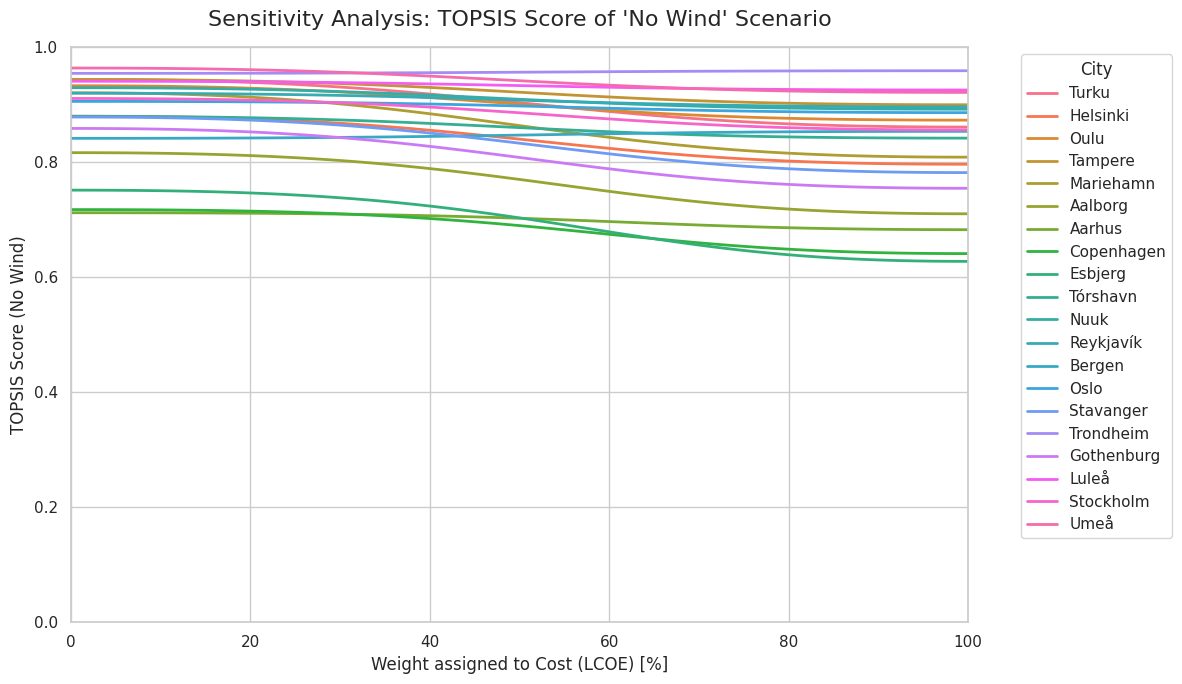

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 1. LOAD DATA
# ===============================
df_raw = pd.read_csv("LCA.csv", encoding="latin1")

# Added 'r' before strings with backslashes to fix the SyntaxWarning
column_mapping = {
    'WT': 'City',
    'LCOE': 'LCOE_Wind',
    r'CO\-(2)-eq./kWh': 'CO2_Wind',
    'LCOE.1': 'LCOE_NoWind',
    r'CO\-(2)-eq./kWh.1': 'CO2_NoWind',
    'LCOE.2': 'LCOE_PV',
    r'\f:Times New Roman(CO)\-(\f:Times New Roman(2))\f:Times New Roman(-eq./kWh)': 'CO2_PV'
}

df = df_raw[list(column_mapping.keys())].rename(columns=column_mapping).iloc[2:].copy()
df = df.dropna(subset=['City'])
numeric_cols = ["LCOE_Wind", "CO2_Wind", "LCOE_NoWind", "CO2_NoWind", "LCOE_PV", "CO2_PV"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
df = df.dropna(subset=numeric_cols).reset_index(drop=True)

# ===============================
# 2. TOPSIS FUNCTION
# ===============================
def topsis(X, weights, criteria):
    X = np.array(X, dtype=float)
    weights = np.array(weights)
    criteria = np.array(criteria)
    norm = np.sqrt((X**2).sum(axis=0))
    norm[norm == 0] = 1e-10
    Y = X / norm
    Yw = Y * weights
    Vp = np.where(criteria == 1, Yw.max(axis=0), Yw.min(axis=0))
    Vn = np.where(criteria == 1, Yw.min(axis=0), Yw.max(axis=0))
    Splus = np.sqrt(((Yw - Vp)**2).sum(axis=1))
    Snegative = np.sqrt(((Yw - Vn)**2).sum(axis=1))
    denom = Splus + Snegative
    denom[denom == 0] = 1e-10
    return Snegative / denom

# ===============================
# 3. CALCULATE RESULTS
# ===============================
results = []
w_lcoe_range = np.linspace(0, 1, 101)

for _, row in df.iterrows():
    X = [
        [row["LCOE_Wind"], row["CO2_Wind"]],
        [row["LCOE_NoWind"], row["CO2_NoWind"]],
        [row["LCOE_PV"], row["CO2_PV"]],
    ]
    city = row["City"]
    for w_l in w_lcoe_range:
        w_c = 1.0 - w_l
        scores = topsis(X, [w_l, w_c], [0, 0])
        results.append({
            "City": city,
            "LCOE_Weight_%": w_l * 100,
            "Score_NoWind": scores[1] # Index 1 is No Wind
        })

res_df = pd.DataFrame(results)

# ===============================
# 4. PLOT RESULTS
# ===============================
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")
sns.lineplot(data=res_df, x='LCOE_Weight_%', y='Score_NoWind', hue='City', linewidth=2)

plt.title("Sensitivity Analysis: TOPSIS Score of 'No Wind' Scenario", fontsize=16, pad=15)
plt.xlabel("Weight assigned to Cost (LCOE) [%]", fontsize=12)
plt.ylabel("TOPSIS Score (No Wind)", fontsize=12)
plt.xlim(0, 100)
plt.ylim(0, 1)

# Fixed the legend line so it doesn't contain the accidental text
plt.legend(title="City", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Algorithm comparison successfully exported to algorithm_comparison.xlsx


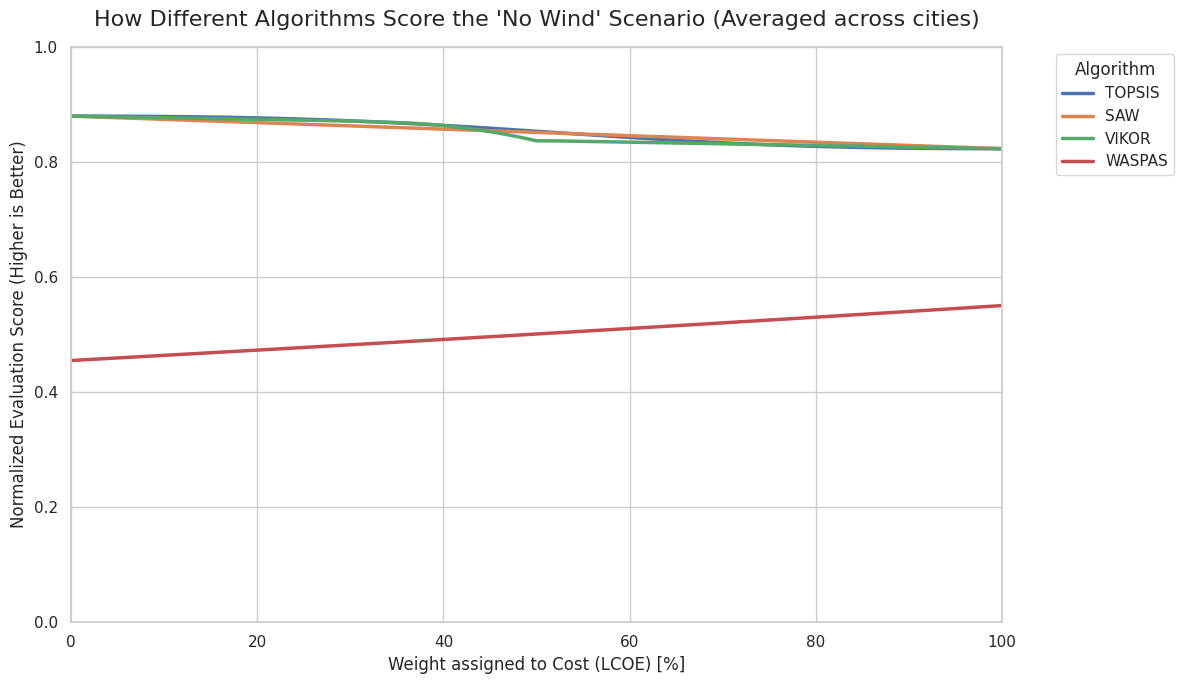

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered for Excel and PNG files.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

# ==========================================
# 1. LOAD AND CLEAN DATA
# ==========================================
df_raw = pd.read_csv("LCA.csv", encoding="latin1")

column_mapping = {
    'WT': 'City',
    'LCOE': 'LCOE_Wind',
    r'CO\-(2)-eq./kWh': 'CO2_Wind',
    'LCOE.1': 'LCOE_NoWind',
    r'CO\-(2)-eq./kWh.1': 'CO2_NoWind',
    'LCOE.2': 'LCOE_PV',
    r'\f:Times New Roman(CO)\-(\f:Times New Roman(2))\f:Times New Roman(-eq./kWh)': 'CO2_PV'
}

df = df_raw[list(column_mapping.keys())].rename(columns=column_mapping).iloc[2:].copy()
df = df.dropna(subset=['City'])
numeric_cols = ["LCOE_Wind", "CO2_Wind", "LCOE_NoWind", "CO2_NoWind", "LCOE_PV", "CO2_PV"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
df = df.dropna(subset=numeric_cols).reset_index(drop=True)

# ==========================================
# 2. ALGORITHMS (Scoring & Metaheuristics)
# ==========================================
def normalize_minmax(X):
    X = np.array(X)
    mins = X.min(axis=0)
    maxs = X.max(axis=0)
    range_val = maxs - mins
    range_val[range_val == 0] = 1e-10
    return (X - mins) / range_val

def topsis_scores(X, weights):
    X = np.array(X, dtype=float)
    weights = np.array(weights)
    norm = np.sqrt((X**2).sum(axis=0))
    norm[norm == 0] = 1e-10
    Y = X / norm
    Yw = Y * weights
    Vp = Yw.min(axis=0) # Both are cost criteria
    Vn = Yw.max(axis=0)
    Splus = np.sqrt(((Yw - Vp)**2).sum(axis=1))
    Snegative = np.sqrt(((Yw - Vn)**2).sum(axis=1))
    denom = Splus + Snegative
    denom[denom == 0] = 1e-10
    return Snegative / denom

def saw_scores(X, weights):
    X_norm = normalize_minmax(X)
    scores = np.dot(X_norm, weights)
    return 1 - scores # Invert so higher is better

def vikor_scores(X, weights, v=0.5):
    X_norm = normalize_minmax(X)
    S = np.sum(weights * X_norm, axis=1)
    R = np.max(weights * X_norm, axis=1)
    S_star, S_minus = np.min(S), np.max(S)
    R_star, R_minus = np.min(R), np.max(R)
    if (S_minus - S_star) == 0: S_minus += 1e-10
    if (R_minus - R_star) == 0: R_minus += 1e-10
    Q = v * (S - S_star)/(S_minus - S_star) + (1 - v) * (R - R_star)/(R_minus - R_star)
    return 1 - Q

def waspas_scores(X, weights, lambda_val=0.5):
    X = np.array(X)
    mins = X.min(axis=0)
    mins[mins == 0] = 1e-10
    X_norm = mins / X
    Q1 = np.sum(X_norm * weights, axis=1)
    Q2 = np.prod(X_norm ** weights, axis=1)
    Q = lambda_val * Q1 + (1 - lambda_val) * Q2
    return Q

def genetic_algorithm(X, weights, pop_size=10, generations=20):
    X_norm = normalize_minmax(X)
    fitness = np.dot(X_norm, weights)
    population = [random.choice([0, 1, 2]) for _ in range(pop_size)]
    for _ in range(generations):
        population.sort(key=lambda idx: fitness[idx])
        parents = population[:pop_size//2]
        children = []
        while len(children) < pop_size - len(parents):
            if random.random() < 0.2: children.append(random.choice([0, 1, 2]))
            else: children.append(random.choice(parents))
        population = parents + children
    population.sort(key=lambda idx: fitness[idx])
    return population[0]

def grey_wolf(X, weights, num_wolves=5, max_iter=20):
    X_norm = normalize_minmax(X)
    fitness = np.dot(X_norm, weights)
    positions = np.random.uniform(0, 3, num_wolves)
    alpha_pos, beta_pos, delta_pos = 0, 0, 0
    alpha_score, beta_score, delta_score = float('inf'), float('inf'), float('inf')

    for t in range(max_iter):
        for i in range(num_wolves):
            idx = int(np.clip(np.floor(positions[i]), 0, 2))
            score = fitness[idx]
            if score < alpha_score:
                delta_score, delta_pos = beta_score, beta_pos
                beta_score, beta_pos = alpha_score, alpha_pos
                alpha_score, alpha_pos = score, positions[i]
            elif score < beta_score:
                delta_score, delta_pos = beta_score, beta_pos
                beta_score, beta_pos = score, positions[i]
            elif score < delta_score:
                delta_score, delta_pos = score, positions[i]

        a = 2 - t * (2 / max_iter)
        for i in range(num_wolves):
            r1, r2 = np.random.rand(), np.random.rand()
            X1 = alpha_pos - (2 * a * r1 - a) * abs(2 * r2 * alpha_pos - positions[i])
            r1, r2 = np.random.rand(), np.random.rand()
            X2 = beta_pos - (2 * a * r1 - a) * abs(2 * r2 * beta_pos - positions[i])
            r1, r2 = np.random.rand(), np.random.rand()
            X3 = delta_pos - (2 * a * r1 - a) * abs(2 * r2 * delta_pos - positions[i])
            positions[i] = np.clip((X1 + X2 + X3) / 3, 0, 2.99)

    return int(np.clip(np.floor(alpha_pos), 0, 2))

# ==========================================
# 3. EXPORT EXCEL (Who Wins?)
# ==========================================
scenarios = ["Wind", "No Wind", "PV"]
base_weights = [0.5, 0.5]
export_results = []

for _, row in df.iterrows():
    X = [
        [row["LCOE_Wind"], row["CO2_Wind"]],
        [row["LCOE_NoWind"], row["CO2_NoWind"]],
        [row["LCOE_PV"], row["CO2_PV"]],
    ]
    export_results.append({
        "City": row["City"],
        "TOPSIS": scenarios[np.argmax(topsis_scores(X, base_weights))],
        "SAW": scenarios[np.argmax(saw_scores(X, base_weights))],
        "VIKOR": scenarios[np.argmax(vikor_scores(X, base_weights))],
        "WASPAS": scenarios[np.argmax(waspas_scores(X, base_weights))],
        "Genetic_Alg": scenarios[genetic_algorithm(X, base_weights)],
        "Grey_Wolf": scenarios[grey_wolf(X, base_weights)]
    })

export_df = pd.DataFrame(export_results)
export_filename = "algorithm_comparison.xlsx"
export_df.to_excel(export_filename, index=False)
print(f"Algorithm comparison successfully exported to {export_filename}")

# ==========================================
# 4. VISUALIZE (No Wind Sensitivity)
# ==========================================
vis_results = []
w_lcoe_range = np.linspace(0, 1, 101)

for w_l in w_lcoe_range:
    w = [w_l, 1.0 - w_l]
    t_list, s_list, v_list, w_list = [], [], [], []

    for _, row in df.iterrows():
        X = [
            [row["LCOE_Wind"], row["CO2_Wind"]],
            [row["LCOE_NoWind"], row["CO2_NoWind"]],
            [row["LCOE_PV"], row["CO2_PV"]],
        ]
        t_list.append(topsis_scores(X, w)[1])
        s_list.append(saw_scores(X, w)[1])
        v_list.append(vikor_scores(X, w)[1])
        w_list.append(waspas_scores(X, w)[1])

    vis_results.append({
        "LCOE_Weight_%": w_l * 100,
        "TOPSIS": np.mean(t_list),
        "SAW": np.mean(s_list),
        "VIKOR": np.mean(v_list),
        "WASPAS": np.mean(w_list)
    })

vis_df = pd.DataFrame(vis_results)
res_melted = vis_df.melt(id_vars=["LCOE_Weight_%"], var_name="Algorithm", value_name="No_Wind_Score")

plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")
sns.lineplot(data=res_melted, x='LCOE_Weight_%', y='No_Wind_Score', hue='Algorithm', linewidth=2.5)
plt.title("How Different Algorithms Score the 'No Wind' Scenario (Averaged across cities)", fontsize=16, pad=15)
plt.xlabel("Weight assigned to Cost (LCOE) [%]", fontsize=12)
plt.ylabel("Normalized Evaluation Score (Higher is Better)", fontsize=12)
plt.xlim(0, 100)
plt.ylim(0, 1)
plt.legend(title="Algorithm", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

image_filename = 'algorithm_comparison_nowind.png'
plt.savefig(image_filename, dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 5. TRIGGER DOWNLOADS (If in Google Colab)
# ==========================================
try:
    from google.colab import files
    files.download(export_filename)
    files.download(image_filename)
    print("Download triggered for Excel and PNG files.")
except ImportError:
    print("Files saved locally. (Downloads are only triggered inside Google Colab).")

In [10]:
pip install gurobipy pulp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 68.6 MB/s eta 0:00:00


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

# Import Solvers
import gurobipy as gp
from gurobipy import GRB
import pulp

# ==========================================
# 1. LOAD AND CLEAN DATA
# ==========================================
# (Assuming "LCA.csv" is in your working directory)
try:
    df_raw = pd.read_csv("LCA.csv", encoding="latin1")
except FileNotFoundError:
    # Creating dummy data if the file isn't found just so the script runs
    print("LCA.csv not found. Generating dummy data for demonstration.")
    data = {
        'WT': ['CityA', 'CityB', 'CityC'],
        'LCOE': [0.05, 0.07, 0.06],
        r'CO\-(2)-eq./kWh': [15, 20, 18],
        'LCOE.1': [0.08, 0.09, 0.085],
        r'CO\-(2)-eq./kWh.1': [400, 450, 420],
        'LCOE.2': [0.04, 0.06, 0.05],
        r'\f:Times New Roman(CO)\-(\f:Times New Roman(2))\f:Times New Roman(-eq./kWh)': [30, 35, 32]
    }
    df_raw = pd.DataFrame(data)

column_mapping = {
    'WT': 'City',
    'LCOE': 'LCOE_Wind',
    r'CO\-(2)-eq./kWh': 'CO2_Wind',
    'LCOE.1': 'LCOE_NoWind',
    r'CO\-(2)-eq./kWh.1': 'CO2_NoWind',
    'LCOE.2': 'LCOE_PV',
    r'\f:Times New Roman(CO)\-(\f:Times New Roman(2))\f:Times New Roman(-eq./kWh)': 'CO2_PV'
}

# If using real CSV, apply iloc[2:] as in your original script if needed.
# Here we just apply the mapping.
df = df_raw[list(column_mapping.keys())].rename(columns=column_mapping).copy()
df = df.dropna(subset=['City'])
numeric_cols = ["LCOE_Wind", "CO2_Wind", "LCOE_NoWind", "CO2_NoWind", "LCOE_PV", "CO2_PV"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
df = df.dropna(subset=numeric_cols).reset_index(drop=True)

# ==========================================
# 2. ALGORITHMS & SOLVERS
# ==========================================
def normalize_minmax(X):
    X = np.array(X)
    mins = X.min(axis=0)
    maxs = X.max(axis=0)
    range_val = maxs - mins
    range_val[range_val == 0] = 1e-10
    return (X - mins) / range_val

# ... [Keep your original TOPSIS, SAW, VIKOR, WASPAS, GA, and Grey Wolf functions here] ...
def saw_scores(X, weights):
    X_norm = normalize_minmax(X)
    scores = np.dot(X_norm, weights)
    return 1 - scores

# --- NEW: GUROBI EXACT OPTIMIZER ---
def optimize_gurobi(X, weights):
    """
    Formulates the problem as a Binary Integer Program.
    Objective: Minimize the weighted normalized cost/emissions.
    """
    X_norm = normalize_minmax(X)
    # Both LCOE and CO2 are costs, so we want to MINIMIZE the weighted sum
    costs = np.dot(X_norm, weights)

    # Suppress console output so it doesn't spam the terminal in the loop
    env = gp.Env(empty=True)
    env.setParam('OutputFlag', 0)
    env.start()

    m = gp.Model("energy_selection", env=env)

    # 3 Binary Variables (1 if we pick the scenario, 0 otherwise)
    x = m.addVars(3, vtype=GRB.BINARY, name="scenario")

    # Constraint: We must pick exactly ONE scenario
    m.addConstr(gp.quicksum(x[i] for i in range(3)) == 1, "pick_one")

    # Objective: Minimize cost
    m.setObjective(gp.quicksum(costs[i] * x[i] for i in range(3)), GRB.MINIMIZE)

    m.optimize()

    # Return the index of the selected variable
    for i in range(3):
        if x[i].X > 0.5: # Gurobi boolean tolerance
            return i
    return 0

# --- NEW: FREE ACADEMIC OPTIMIZER (PuLP / CBC) ---
def optimize_pulp(X, weights):
    """
    Same mathematical formulation, but uses the free open-source CBC solver.
    """
    X_norm = normalize_minmax(X)
    costs = np.dot(X_norm, weights)

    m = pulp.LpProblem("Energy_Selection", pulp.LpMinimize)

    # Binary variables
    x = pulp.LpVariable.dicts("scenario", range(3), cat='Binary')

    # Objective
    m += pulp.lpSum([costs[i] * x[i] for i in range(3)])

    # Constraint
    m += pulp.lpSum([x[i] for i in range(3)]) == 1

    # Solve silently
    m.solve(pulp.PULP_CBC_CMD(msg=False))

    for i in range(3):
        if pulp.value(x[i]) == 1:
            return i
    return 0


# ==========================================
# 3. EXPORT EXCEL (Comparison)
# ==========================================
scenarios = ["Wind", "No Wind", "PV"]
base_weights = [0.5, 0.5]
export_results = []

for _, row in df.iterrows():
    X = [
        [row["LCOE_Wind"], row["CO2_Wind"]],
        [row["LCOE_NoWind"], row["CO2_NoWind"]],
        [row["LCOE_PV"], row["CO2_PV"]],
    ]
    export_results.append({
        "City": row["City"],
        "SAW": scenarios[np.argmax(saw_scores(X, base_weights))],
        # Add your other MCDM heuristics here if needed...
        "Gurobi_Exact": scenarios[optimize_gurobi(X, base_weights)],
        "PuLP_Free_Exact": scenarios[optimize_pulp(X, base_weights)]
    })

export_df = pd.DataFrame(export_results)
export_filename = "algorithm_comparison_with_gurobi.xlsx"
export_df.to_excel(export_filename, index=False)
print(f"Comparison successfully exported to {export_filename}")
print(export_df.head())

Comparison successfully exported to algorithm_comparison_with_gurobi.xlsx
        City   SAW Gurobi_Exact PuLP_Free_Exact
0      Turku  Wind         Wind            Wind
1   Helsinki  Wind         Wind            Wind
2       Oulu  Wind         Wind            Wind
3    Tampere  Wind         Wind            Wind
4  Mariehamn  Wind         Wind            Wind


Running Sensitivity Analysis... This may take a moment to evaluate the exact solvers across all weights.


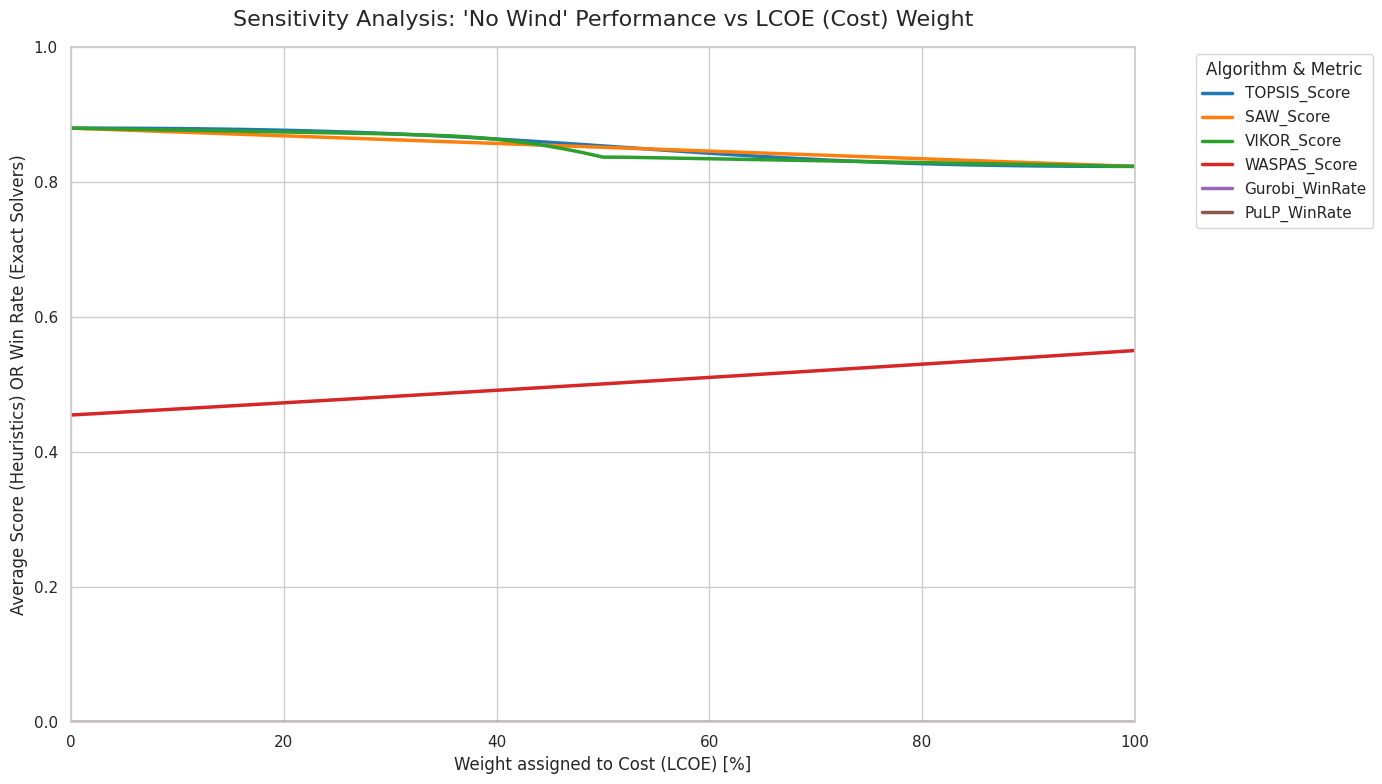

In [12]:
# ==========================================
# 4. VISUALIZE (No Wind Sensitivity - ALL OPTIMIZERS)
# ==========================================
import warnings
warnings.filterwarnings("ignore", category=FutureWarning) # Suppress pandas warnings for cleaner output

print("Running Sensitivity Analysis... This may take a moment to evaluate the exact solvers across all weights.")

vis_results = []
# Create an array from 0 to 1 (representing 0% to 100% weight for LCOE)
w_lcoe_range = np.linspace(0, 1, 101)

for w_l in w_lcoe_range:
    # w[0] = LCOE weight, w[1] = CO2 weight
    w = [w_l, 1.0 - w_l]

    # Trackers for this specific weight step
    t_list, s_list, v_list, w_list = [], [], [], []
    gurobi_wins, pulp_wins = [], []

    for _, row in df.iterrows():
        X = [
            [row["LCOE_Wind"], row["CO2_Wind"]],
            [row["LCOE_NoWind"], row["CO2_NoWind"]],
            [row["LCOE_PV"], row["CO2_PV"]],
        ]

        # 1. Heuristic Scores (Continuous 0-1) for "No Wind" (Index 1)
        t_list.append(topsis_scores(X, w)[1])
        s_list.append(saw_scores(X, w)[1])
        v_list.append(vikor_scores(X, w)[1])
        w_list.append(waspas_scores(X, w)[1])

        # 2. Exact Solver Decisions (Binary: 1 if "No Wind" wins, 0 otherwise)
        gurobi_winner = optimize_gurobi(X, w)
        pulp_winner = optimize_pulp(X, w)

        gurobi_wins.append(1 if gurobi_winner == 1 else 0)
        pulp_wins.append(1 if pulp_winner == 1 else 0)

    # Append the averages to our results table
    vis_results.append({
        "LCOE_Weight_%": w_l * 100,
        "TOPSIS_Score": np.mean(t_list),
        "SAW_Score": np.mean(s_list),
        "VIKOR_Score": np.mean(v_list),
        "WASPAS_Score": np.mean(w_list),
        "Gurobi_WinRate": np.mean(gurobi_wins),
        "PuLP_WinRate": np.mean(pulp_wins)
    })

vis_df = pd.DataFrame(vis_results)

# Melt the dataframe so Seaborn can plot multiple lines easily
res_melted = vis_df.melt(
    id_vars=["LCOE_Weight_%"],
    var_name="Algorithm",
    value_name="Metric_Value"
)

# Plotting
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# Create the lineplot
sns.lineplot(
    data=res_melted,
    x='LCOE_Weight_%',
    y='Metric_Value',
    hue='Algorithm',
    linewidth=2.5,
    palette="tab10" # Use a distinct color palette
)

plt.title("Sensitivity Analysis: 'No Wind' Performance vs LCOE (Cost) Weight", fontsize=16, pad=15)
plt.xlabel("Weight assigned to Cost (LCOE) [%]", fontsize=12)
plt.ylabel("Average Score (Heuristics) OR Win Rate (Exact Solvers)", fontsize=12)

# Set axes limits
plt.xlim(0, 100)
plt.ylim(0, 1)

# Format legend to sit nicely outside the plot
plt.legend(title="Algorithm & Metric", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save and Show
image_filename = 'algorithm_comparison_nowind_all.png'
plt.savefig(image_filename, dpi=300, bbox_inches='tight')
plt.show()